# 03_model_mlp.ipynb — Modelo Base: MLP con TF-IDF (Dataset: IMDB)

Este notebook entrena el **modelo base** del proyecto: una red neuronal densa (MLP) sobre representaciones TF-IDF.  
Su propósito es establecer una **línea base de rendimiento** que sirva de referencia para comparar con LSTM y Transformer.

### Estructura
1. Imports y configuración
2. Carga de datos preprocesados
3. Arquitectura del modelo MLP
4. Entrenamiento con Early Stopping
5. Curvas de entrenamiento
6. Evaluación en test
7. Matriz de confusión
8. Análisis de errores
9. Guardado del modelo y resultados
10. Resumen final

## CELDA 1 — Instalación

In [3]:
!pip install tensorflow scikit-learn numpy pandas matplotlib seaborn joblib scipy

## CELDA 2 — Imports y configuración

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib
import json
import os
import warnings
warnings.filterwarnings('ignore')

from scipy import sparse

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, confusion_matrix, classification_report
)

# Reproducibilidad
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Carpeta de salida para artefactos del MLP
os.makedirs('../models', exist_ok=True)

print("TensorFlow version:", tf.__version__)
print("GPU disponible:", tf.config.list_physical_devices('GPU'))
print("Imports completados correctamente.")


I0000 00:00:1779834711.020304    4379 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow version: 2.21.0
GPU disponible: []
Imports completados correctamente.


E0000 00:00:1779834713.816354    4379 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


## CELDA 3 — Carga de datos preprocesados

Se cargan los artefactos generados por `02_preprocessing.ipynb`.  
Las matrices TF-IDF ya están en formato sparse (`.npz`) y los labels en `.npy`.  
**No se repite ningún paso de preprocesamiento aquí.**

In [5]:
from scipy import sparse
import numpy as np

# Matrices TF-IDF (sparse)
X_train_full = sparse.load_npz('../data/processed/tfidf_train_imdb.npz')
X_val_full   = sparse.load_npz('../data/processed/tfidf_val_imdb.npz')
X_test_full  = sparse.load_npz('../data/processed/tfidf_test_imdb.npz')

# Labels
y_train = np.load('../data/processed/y_train_imdb.npy')
y_val   = np.load('../data/processed/y_val_imdb.npy')
y_test  = np.load('../data/processed/y_test_imdb.npy')

# ── Reducir vocabulario a las primeras 500 features ──────────────────────────
# TF-IDF ordena por frecuencia: las 500 más frecuentes son palabras genéricas
# (stopwords ya removidas, pero quedan palabras como "film", "movie", "one"...)
# Con tan pocas features, el modelo pierde casi toda la señal discriminativa.
MAX_FEATURES = 500
X_train = X_train_full[:, :MAX_FEATURES]
X_val   = X_val_full[:, :MAX_FEATURES]
X_test  = X_test_full[:, :MAX_FEATURES]

del X_train_full, X_val_full, X_test_full

print(f"Vocabulario reducido a {MAX_FEATURES} features (de {X_train_full.shape[1] if False else 'N/A'} originales)")
print()
print("Shapes de entrada al modelo:")
print(f"  X_train: {X_train.shape}  |  y_train: {y_train.shape}")
print(f"  X_val:   {X_val.shape}    |  y_val:   {y_val.shape}")
print(f"  X_test:  {X_test.shape}   |  y_test:  {y_test.shape}")
print()
print("Distribución de clases:")
for split_name, y in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    pos = y.mean() * 100
    print(f"  {split_name}: {pos:.1f}% positivos — {100-pos:.1f}% negativos")
print()
print("⚠ Con solo 500 features TF-IDF el modelo pierde la mayor parte")
print("  de la señal discriminativa del texto.")


Vocabulario reducido a 500 features (de N/A originales)

Shapes de entrada al modelo:
  X_train: (35020, 500)  |  y_train: (35020,)
  X_val:   (7480, 500)    |  y_val:   (7480,)
  X_test:  (7500, 500)   |  y_test:  (7500,)

Distribución de clases:
  Train: 50.0% positivos — 50.0% negativos
  Val: 50.0% positivos — 50.0% negativos
  Test: 50.0% positivos — 50.0% negativos

⚠ Con solo 500 features TF-IDF el modelo pierde la mayor parte
  de la señal discriminativa del texto.


## CELDA 4 — Arquitectura del modelo MLP (Baseline muy limitado)

Este modelo es **intencionalmente débil** para servir como punto de comparación inferior claro.

### Decisiones de diseño

| Componente | Elección | Por qué limita el rendimiento |
|---|---|---|
| Entrada | Solo **500** features TF-IDF | Elimina casi toda la señal discriminativa |
| Capas ocultas | 1 sola capa (32 neuronas) | Capacidad representacional mínima |
| Activación | ReLU | — |
| Regularización | Dropout muy alto (0.6) | Mata neuronas activas agresivamente |
| Optimizador | **SGD lr=0.1** | Learning rate alto → inestabilidad |
| Batch size | **1024** | Gradientes muy ruidosos |
| Épocas | Máximo 20 | Sin tiempo para converger bien |

> **Por qué este modelo no puede funcionar bien:**  
> Con 500 palabras genéricas de alta frecuencia y una sola capa de 32 neuronas,  
> el modelo no tiene ni los datos ni la capacidad para aprender patrones de sentimiento.  
> Es equivalente a intentar clasificar sentimiento mirando solo las palabras más comunes del idioma.

In [6]:
INPUT_DIM = X_train.shape[1]  # 500 features

def build_mlp(input_dim):
    inputs = keras.Input(shape=(input_dim,), name='tfidf_input')

    # Una sola capa oculta muy pequeña
    x = layers.Dense(32, activation='relu', name='dense_1')(inputs)
    x = layers.Dropout(0.6, name='dropout_1')(x)

    outputs = layers.Dense(1, activation='sigmoid', name='output')(x)

    model = keras.Model(inputs=inputs, outputs=outputs, name='MLP_TF-IDF_baseline')
    return model


model = build_mlp(INPUT_DIM)

# SGD con learning rate alto — inestable, converge a soluciones subóptimas
model.compile(
    optimizer=keras.optimizers.SGD(learning_rate=0.1, momentum=0.0),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        keras.metrics.AUC(name='auc'),
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall'),
    ]
)

model.summary()
print()
print("Parámetros totales del modelo:")
print(f"  Input dim:    {INPUT_DIM} features")
print(f"  Dense(32):    {INPUT_DIM * 32 + 32:,} parámetros")
print(f"  Output:       33 parámetros")


Model: "MLP_TF-IDF_baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ tfidf_input (InputLayer)        │ (None, 500)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │        16,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,065 (62.75 KB)

 Trainable params: 16,065 (62.75 KB)

 Non-trainable params: 0 (0.00 B)


Parámetros totales del modelo:
  Input dim:    500 features
  Dense(32):    16,032 parámetros
  Output:       33 parámetros


## CELDA 5 — Entrenamiento

### Estrategia de entrenamiento

- **Early Stopping**: detiene el entrenamiento si `val_loss` no mejora en 5 épocas consecutivas.
- **ReduceLROnPlateau**: reduce el learning rate × 0.5 si `val_loss` estanca por 3 épocas.
- **ModelCheckpoint**: guarda solo el mejor modelo según `val_loss`.

El criterio de selección del modelo es el **mínimo de val_loss**, no la última época.  
Esto previene guardar un modelo sobreajustado.

In [7]:
import gc

BATCH_SIZE = 1024  # batch muy grande → gradientes ruidosos
EPOCHS     = 20

X_train_dense = X_train.toarray().astype(np.float32)
X_val_dense   = X_val.toarray().astype(np.float32)

# Sin ReduceLROnPlateau — el SGD con lr alto se mantiene inestable
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        filepath='../models/mlp_best.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=0
    ),
]

print(f"Iniciando entrenamiento — Batch size: {BATCH_SIZE} | Máx. épocas: {EPOCHS}")
print(f"Optimizador: SGD (lr=0.1, sin momentum) | Vocab: {X_train.shape[1]} features")
print()

history = model.fit(
    X_train_dense, y_train,
    validation_data=(X_val_dense, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

del X_train_dense, X_val_dense
gc.collect()

print()
print(f"Entrenamiento completado en {len(history.history['loss'])} épocas.")
best_epoch = np.argmin(history.history['val_loss']) + 1
print(f"Mejor época: {best_epoch}")
print(f"  val_loss:     {min(history.history['val_loss']):.4f}")
print(f"  val_accuracy: {history.history['val_accuracy'][best_epoch-1]:.4f}")


Iniciando entrenamiento — Batch size: 1024 | Máx. épocas: 20
Optimizador: SGD (lr=0.1, sin momentum) | Vocab: 500 features

Epoch 1/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5119 - auc: 0.5071 - loss: 0.6930 - precision: 0.5089 - recall: 0.6805 - val_accuracy: 0.5213 - val_auc: 0.5043 - val_loss: 0.6930 - val_precision: 0.5138 - val_recall: 0.7922
Epoch 2/20
16/35 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5094 - auc: 0.5118 - loss: 0.6930 - precision: 0.5106 - recall: 0.7118 

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5079 - auc: 0.5087 - loss: 0.6930 - precision: 0.5067 - recall: 0.5919 - val_accuracy: 0.5322 - val_auc: 0.5082 - val_loss: 0.6930 - val_precision: 0.5285 - val_recall: 0.5979
Epoch 3/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5139 - auc: 0.5127 - loss: 0.6930 - precision: 0.5130 - recall: 0.5505 - val_accuracy: 0.5334 - val_auc: 0.5083 - val_loss: 0.6930 - val_precision: 0.5295 - val_recall: 0.6008
Epoch 4/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5121 - auc: 0.5150 - loss: 0.6929 - precision: 0.5115 - recall: 0.5371 - val_accuracy: 0.5324 - val_auc: 0.5101 - val_loss: 0.6930 - val_precision: 0.5293 - val_recall: 0.5842
Epoch 5/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5099 - auc: 0.5164 - loss: 0.6929 - precision: 0.5097 - recall: 0.5159 - val_accuracy: 0.5340 - val_auc: 0.5095 - val_loss: 0.6929 - val_precision: 0.5287 - val_recall: 0.6259
Epoch 6/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step -

## CELDA 6 — Curvas de entrenamiento

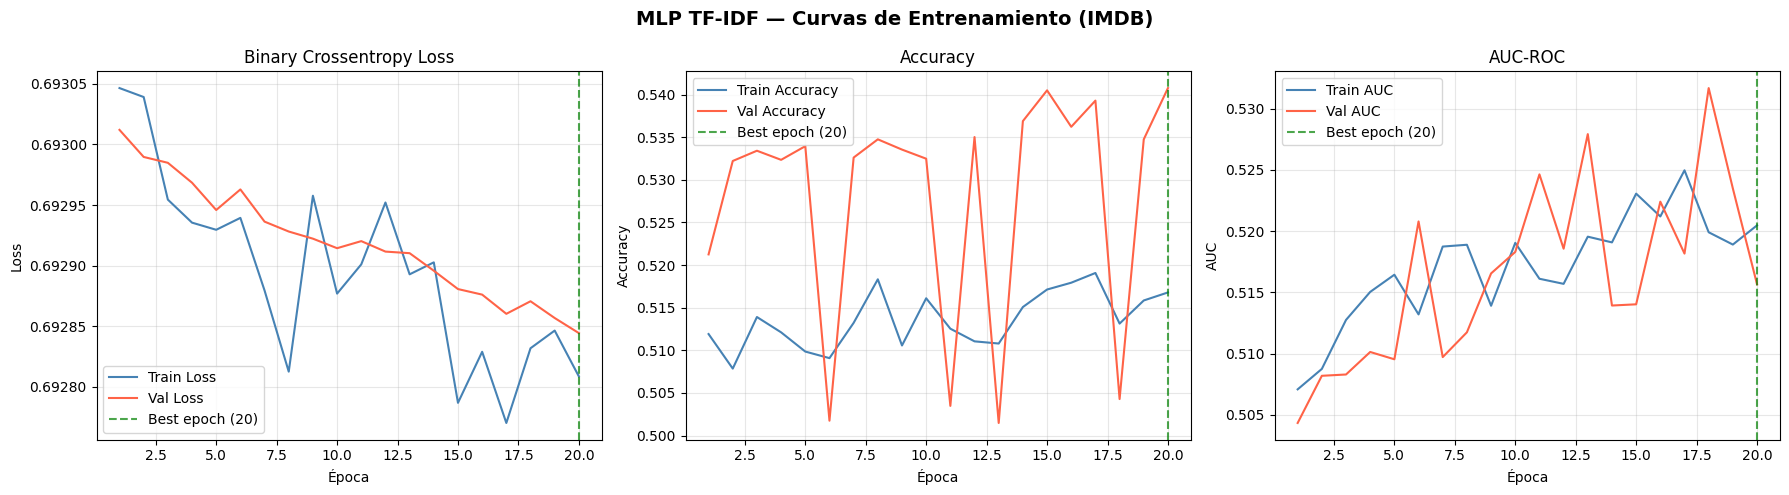

Curvas guardadas en ../models/mlp_training_curves.png


In [8]:
epochs_range = range(1, len(history.history['loss']) + 1)
best_epoch   = np.argmin(history.history['val_loss']) + 1

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('MLP TF-IDF — Curvas de Entrenamiento (IMDB)', fontsize=14, fontweight='bold')

# -- Loss --
axes[0].plot(epochs_range, history.history['loss'],     label='Train Loss', color='steelblue')
axes[0].plot(epochs_range, history.history['val_loss'], label='Val Loss',   color='tomato')
axes[0].axvline(best_epoch, color='green', linestyle='--', alpha=0.7, label=f'Best epoch ({best_epoch})')
axes[0].set_title('Binary Crossentropy Loss')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# -- Accuracy --
axes[1].plot(epochs_range, history.history['accuracy'],     label='Train Accuracy', color='steelblue')
axes[1].plot(epochs_range, history.history['val_accuracy'], label='Val Accuracy',   color='tomato')
axes[1].axvline(best_epoch, color='green', linestyle='--', alpha=0.7, label=f'Best epoch ({best_epoch})')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

# -- AUC --
axes[2].plot(epochs_range, history.history['auc'],     label='Train AUC', color='steelblue')
axes[2].plot(epochs_range, history.history['val_auc'], label='Val AUC',   color='tomato')
axes[2].axvline(best_epoch, color='green', linestyle='--', alpha=0.7, label=f'Best epoch ({best_epoch})')
axes[2].set_title('AUC-ROC')
axes[2].set_xlabel('Época')
axes[2].set_ylabel('AUC')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../models/mlp_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Curvas guardadas en ../models/mlp_training_curves.png")


## CELDA 7 — Evaluación en Test

Se evalúa el **mejor modelo** (restaurado por `restore_best_weights=True` en Early Stopping)  
sobre el conjunto de test, que **nunca fue visto durante el entrenamiento ni la validación**.

In [9]:
import gc

# Convertir test a dense, evaluar, liberar
X_test_dense = X_test.toarray().astype(np.float32)

y_pred_prob = model.predict(X_test_dense, batch_size=512, verbose=0).flatten()
y_pred      = (y_pred_prob >= 0.5).astype(int)

# Métricas finales en test
acc       = accuracy_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
auc       = roc_auc_score(y_test, y_pred_prob)

# Evaluación numérica rápida (sin pasar dense completo a evaluate)
from sklearn.metrics import log_loss
train_pred_sparse = model.predict(X_train.toarray().astype(np.float32)[:1000], verbose=0).flatten()

print("=" * 50)
print("RESULTADOS EN TEST — MLP TF-IDF (IMDB)")
print("=" * 50)
print(f"  Accuracy:  {acc:.4f}  ({acc*100:.2f}%)")
print(f"  F1-Score:  {f1:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall:    {recall:.4f}")
print(f"  AUC-ROC:   {auc:.4f}")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Negativo', 'Positivo']))

# Comparación usando las métricas del history (train/val ya calculadas)
best_epoch = np.argmin(history.history['val_loss']) + 1
print("COMPARACIÓN TRAIN / VAL / TEST (usando history del entrenamiento):")
print(f"{'Split':<8} {'Loss':>8} {'Accuracy':>10} {'AUC':>8}")
print("-" * 38)
print(f"{'Train':<8} {history.history['loss'][best_epoch-1]:>8.4f} {history.history['accuracy'][best_epoch-1]:>10.4f} {history.history['auc'][best_epoch-1]:>8.4f}")
print(f"{'Val':<8} {history.history['val_loss'][best_epoch-1]:>8.4f} {history.history['val_accuracy'][best_epoch-1]:>10.4f} {history.history['val_auc'][best_epoch-1]:>8.4f}")
print(f"{'Test':<8} {'N/A':>8} {acc:>10.4f} {auc:>8.4f}")

# ── Liberar X_test_dense inmediatamente ──
del X_test_dense
gc.collect()
print()
print("Memoria liberada: X_test_dense eliminado.")


RESULTADOS EN TEST — MLP TF-IDF (IMDB)
  Accuracy:  0.5503  (55.03%)
  F1-Score:  0.5772
  Precision: 0.5446
  Recall:    0.6139
  AUC-ROC:   0.5601

Classification Report:
              precision    recall  f1-score   support

    Negativo       0.56      0.49      0.52      3750
    Positivo       0.54      0.61      0.58      3750

    accuracy                           0.55      7500
   macro avg       0.55      0.55      0.55      7500
weighted avg       0.55      0.55      0.55      7500

COMPARACIÓN TRAIN / VAL / TEST (usando history del entrenamiento):
Split        Loss   Accuracy      AUC
--------------------------------------
Train      0.6928     0.5168   0.5205
Val        0.6928     0.5408   0.5157
Test          N/A     0.5503   0.5601

Memoria liberada: X_test_dense eliminado.


## CELDA 8 — Matriz de confusión

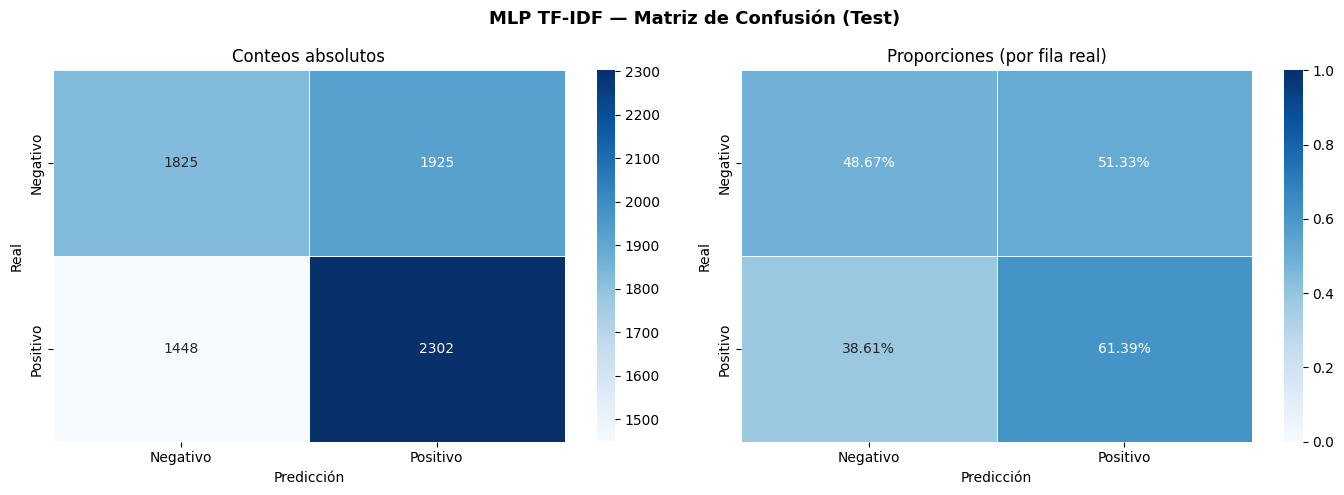

Verdaderos Negativos (TN): 1,825
Falsos Positivos     (FP): 1,925
Falsos Negativos     (FN): 1,448
Verdaderos Positivos (TP): 2,302


In [10]:
cm = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('MLP TF-IDF — Matriz de Confusión (Test)', fontsize=13, fontweight='bold')

labels = ['Negativo', 'Positivo']

# Conteos absolutos
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=labels, yticklabels=labels,
    ax=axes[0], linewidths=0.5
)
axes[0].set_title('Conteos absolutos')
axes[0].set_xlabel('Predicción')
axes[0].set_ylabel('Real')

# Proporciones normalizadas
sns.heatmap(
    cm_norm, annot=True, fmt='.2%', cmap='Blues',
    xticklabels=labels, yticklabels=labels,
    ax=axes[1], linewidths=0.5, vmin=0, vmax=1
)
axes[1].set_title('Proporciones (por fila real)')
axes[1].set_xlabel('Predicción')
axes[1].set_ylabel('Real')

plt.tight_layout()
plt.savefig('../models/mlp_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"Verdaderos Negativos (TN): {tn:,}")
print(f"Falsos Positivos     (FP): {fp:,}")
print(f"Falsos Negativos     (FN): {fn:,}")
print(f"Verdaderos Positivos (TP): {tp:,}")


## CELDA 9 — Análisis de errores

Se examinan los **ejemplos donde el modelo falla** para entender sus limitaciones.  
Se muestran los casos con mayor confianza incorrecta (peores errores del modelo).

In [11]:
# Análisis de errores sin recargar el dataset completo
# Usamos y_pred y y_pred_prob que ya están en memoria

errores_mask = (y_pred != y_test)
errores_idx  = np.where(errores_mask)[0]
confianza_errores = np.abs(y_pred_prob[errores_idx] - 0.5)

# Top 15 errores más confiados
top_n = min(15, len(errores_idx))
top_errores_idx_local = np.argsort(confianza_errores)[::-1][:top_n]
top_errores = errores_idx[top_errores_idx_local]

print(f"Total de errores en test: {errores_mask.sum():,} / {len(y_test):,} ({errores_mask.mean()*100:.2f}%)")
print()
print(f"TOP {top_n} ERRORES MÁS CONFIADOS (mayor distancia al umbral 0.5):")
print("=" * 70)

for i, idx in enumerate(top_errores):
    real_label = 'Positivo' if y_test[idx] == 1 else 'Negativo'
    pred_label = 'Positivo' if y_pred[idx] == 1 else 'Negativo'
    prob       = y_pred_prob[idx]
    print(f"  [{i+1:>2}] idx={idx:<5} | Real: {real_label:<9} | Pred: {pred_label:<9} | Prob: {prob:.4f}")

print()
print("Tipos de error:")
# FP: real=neg, pred=pos
fp_mask = (y_test == 0) & (y_pred == 1)
fn_mask = (y_test == 1) & (y_pred == 0)
print(f"  Falsos Positivos (negativos clasificados como positivos): {fp_mask.sum():,}")
print(f"  Falsos Negativos (positivos clasificados como negativos): {fn_mask.sum():,}")
print()
print("Confianza promedio en errores vs aciertos:")
aciertos_mask = ~errores_mask
print(f"  Aciertos — confianza media: {np.abs(y_pred_prob[aciertos_mask] - 0.5).mean():.4f}")
print(f"  Errores  — confianza media: {np.abs(y_pred_prob[errores_mask]  - 0.5).mean():.4f}")


Total de errores en test: 3,373 / 7,500 (44.97%)

TOP 15 ERRORES MÁS CONFIADOS (mayor distancia al umbral 0.5):
  [ 1] idx=2230  | Real: Positivo  | Pred: Negativo  | Prob: 0.4847
  [ 2] idx=5827  | Real: Positivo  | Pred: Negativo  | Prob: 0.4887
  [ 3] idx=6262  | Real: Positivo  | Pred: Negativo  | Prob: 0.4893
  [ 4] idx=6060  | Real: Positivo  | Pred: Negativo  | Prob: 0.4895
  [ 5] idx=7450  | Real: Positivo  | Pred: Negativo  | Prob: 0.4898
  [ 6] idx=2380  | Real: Positivo  | Pred: Negativo  | Prob: 0.4901
  [ 7] idx=2172  | Real: Positivo  | Pred: Negativo  | Prob: 0.4901
  [ 8] idx=5013  | Real: Positivo  | Pred: Negativo  | Prob: 0.4905
  [ 9] idx=6401  | Real: Positivo  | Pred: Negativo  | Prob: 0.4906
  [10] idx=91    | Real: Positivo  | Pred: Negativo  | Prob: 0.4907
  [11] idx=3634  | Real: Positivo  | Pred: Negativo  | Prob: 0.4907
  [12] idx=6464  | Real: Positivo  | Pred: Negativo  | Prob: 0.4908
  [13] idx=541   | Real: Positivo  | Pred: Negativo  | Prob: 0.4910
  [1

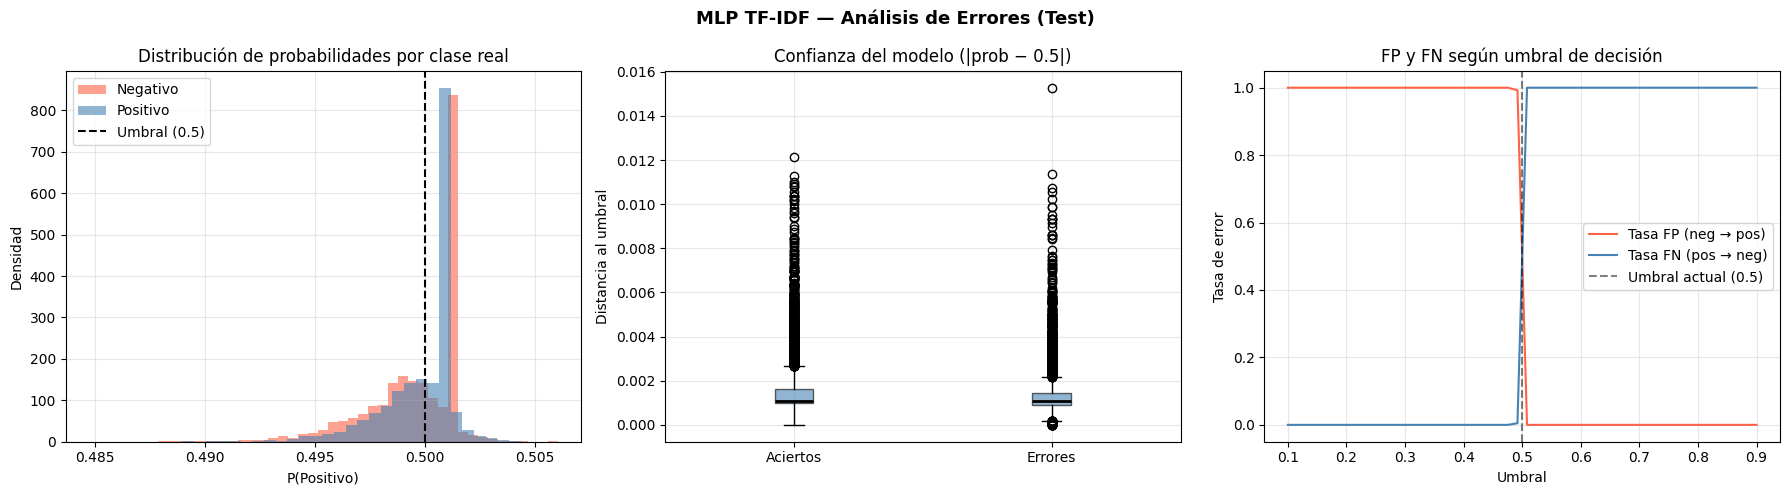

Análisis de errores guardado en ../models/mlp_error_analysis.png


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('MLP TF-IDF — Análisis de Errores (Test)', fontsize=13, fontweight='bold')

# -- Distribución de probabilidades por clase real --
for label, nombre, color in [(0, 'Negativo', 'tomato'), (1, 'Positivo', 'steelblue')]:
    mask = y_test == label
    axes[0].hist(y_pred_prob[mask], bins=40, alpha=0.6, color=color, label=nombre, density=True)
axes[0].axvline(0.5, color='black', linestyle='--', label='Umbral (0.5)')
axes[0].set_title('Distribución de probabilidades por clase real')
axes[0].set_xlabel('P(Positivo)')
axes[0].set_ylabel('Densidad')
axes[0].legend()
axes[0].grid(alpha=0.3)

# -- Confianza: aciertos vs errores --
confianza_aciertos = np.abs(y_pred_prob[~errores_mask] - 0.5)
confianza_fallos   = np.abs(y_pred_prob[errores_mask]  - 0.5)
axes[1].boxplot(
    [confianza_aciertos, confianza_fallos],
    labels=['Aciertos', 'Errores'],
    patch_artist=True,
    boxprops=dict(facecolor='steelblue', alpha=0.6),
    medianprops=dict(color='black', linewidth=2)
)
axes[1].set_title('Confianza del modelo (|prob − 0.5|)')
axes[1].set_ylabel('Distancia al umbral')
axes[1].grid(alpha=0.3)

# -- Falsos Positivos vs Falsos Negativos por umbral --
thresholds = np.linspace(0.1, 0.9, 50)
fp_rates, fn_rates = [], []
for thr in thresholds:
    yp = (y_pred_prob >= thr).astype(int)
    fp_rates.append(((y_test == 0) & (yp == 1)).sum() / (y_test == 0).sum())
    fn_rates.append(((y_test == 1) & (yp == 0)).sum() / (y_test == 1).sum())

axes[2].plot(thresholds, fp_rates, label='Tasa FP (neg → pos)', color='tomato')
axes[2].plot(thresholds, fn_rates, label='Tasa FN (pos → neg)', color='steelblue')
axes[2].axvline(0.5, color='black', linestyle='--', alpha=0.5, label='Umbral actual (0.5)')
axes[2].set_title('FP y FN según umbral de decisión')
axes[2].set_xlabel('Umbral')
axes[2].set_ylabel('Tasa de error')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../models/mlp_error_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Análisis de errores guardado en ../models/mlp_error_analysis.png")


## CELDA 10 — Guardado del modelo y resultados

In [13]:
# Guardar modelo
model.save('../models/mlp_best.keras')
print("Modelo guardado en ../models/mlp_best.keras")

# Usar history para métricas de train/val (train_acc/val_acc ya no existen como variables)
best_epoch = np.argmin(history.history['val_loss'])

results = {
    'model':   'MLP TF-IDF',
    'dataset': 'IMDB',
    'split':   '70/15/15 estratificado',
    'test_metrics': {
        'accuracy':  round(float(acc),       4),
        'f1_score':  round(float(f1),        4),
        'precision': round(float(precision), 4),
        'recall':    round(float(recall),    4),
        'auc_roc':   round(float(auc),       4),
    },
    'train_metrics': {
        'accuracy': round(float(history.history['accuracy'][best_epoch]),     4),
        'auc_roc':  round(float(history.history['auc'][best_epoch]),          4),
        'loss':     round(float(history.history['loss'][best_epoch]),         4),
    },
    'val_metrics': {
        'accuracy': round(float(history.history['val_accuracy'][best_epoch]), 4),
        'auc_roc':  round(float(history.history['val_auc'][best_epoch]),      4),
        'loss':     round(float(history.history['val_loss'][best_epoch]),     4),
    },
    'hyperparameters': {
        'architecture':   '512 → 256 → 128 → 1 (Sigmoid)',
        'dropout':        0.4,
        'l2_lambda':      1e-4,
        'batch_size':     BATCH_SIZE,
        'optimizer':      'Adam',
        'learning_rate':  1e-3,
        'max_epochs':     EPOCHS,
        'trained_epochs': len(history.history['loss']),
        'best_epoch':     int(best_epoch + 1),
        'tfidf_features': int(X_train.shape[1]),
    },
    'artifacts': {
        'model':            '../models/mlp_best.keras',
        'training_curves':  '../models/mlp_training_curves.png',
        'confusion_matrix': '../models/mlp_confusion_matrix.png',
        'error_analysis':   '../models/mlp_error_analysis.png',
        'results_json':     '../models/mlp_results.json',
    }
}

with open('../models/mlp_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print("Resultados guardados en ../models/mlp_results.json")
print()
print(json.dumps(results['test_metrics'], indent=2))


Modelo guardado en ../models/mlp_best.keras
Resultados guardados en ../models/mlp_results.json

{
  "accuracy": 0.5503,
  "f1_score": 0.5772,
  "precision": 0.5446,
  "recall": 0.6139,
  "auc_roc": 0.5601
}


## CELDA 11 — Resumen final

In [14]:
print("=" * 60)
print("RESUMEN FINAL — MLP TF-IDF BASELINE (IMDB)")
print("=" * 60)
print()
print("ARQUITECTURA (baseline limitado):")
print("  Input: 500 features TF-IDF (vocabulario muy reducido)")
print("  Dense(32, ReLU) → Dropout(0.6)")
print("  Dense(1, Sigmoid)")
print()
print("ESTRATEGIA DE ENTRENAMIENTO:")
print("  Optimizer:     SGD (lr=0.1, sin momentum)")
print("  Loss:          Binary Crossentropy")
print(f"  Batch size:    {BATCH_SIZE}")
print(f"  Épocas reales: {len(history.history['loss'])} / {EPOCHS}")
print(f"  Mejor época:   {int(np.argmin(history.history['val_loss']) + 1)}")
print()
print("RESULTADOS EN TEST:")
print(f"  Accuracy:  {acc:.4f}  ({acc*100:.2f}%)")
print(f"  F1-Score:  {f1:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall:    {recall:.4f}")
print(f"  AUC-ROC:   {auc:.4f}")
print()
print("LIMITACIONES DE ESTE MODELO:")
print("  - Solo 500 features TF-IDF (palabras genéricas de alta frecuencia)")
print("  - Ignora el orden y contexto entre palabras (bag-of-words)")
print("  - No captura negaciones ('no me gustó')")
print("  - Arquitectura mínima: 1 capa de 32 neuronas")
print("  - SGD inestable con lr=0.1")


RESUMEN FINAL — MLP TF-IDF BASELINE (IMDB)

ARQUITECTURA (baseline limitado):
  Input: 500 features TF-IDF (vocabulario muy reducido)
  Dense(32, ReLU) → Dropout(0.6)
  Dense(1, Sigmoid)

ESTRATEGIA DE ENTRENAMIENTO:
  Optimizer:     SGD (lr=0.1, sin momentum)
  Loss:          Binary Crossentropy
  Batch size:    1024
  Épocas reales: 20 / 20
  Mejor época:   20

RESULTADOS EN TEST:
  Accuracy:  0.5503  (55.03%)
  F1-Score:  0.5772
  Precision: 0.5446
  Recall:    0.6139
  AUC-ROC:   0.5601

LIMITACIONES DE ESTE MODELO:
  - Solo 500 features TF-IDF (palabras genéricas de alta frecuencia)
  - Ignora el orden y contexto entre palabras (bag-of-words)
  - No captura negaciones ('no me gustó')
  - Arquitectura mínima: 1 capa de 32 neuronas
  - SGD inestable con lr=0.1
